In [713]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [714]:
from sklearn.model_selection import train_test_split

df_train = pd.read_csv('data/train.csv', index_col=0)

df_train, df_validation = train_test_split( df_train, 
                                            train_size=0.85, 
                                            stratify=df_train['Survived'], 
                                            random_state=42)

df_test = pd.read_csv('data/test.csv', index_col=0)
df_submision = pd.read_csv('data/submission_form.csv')

In [715]:
def simple_distribution_analysis(df):
    
    print("🔍 ANALYZING DATA...")
    print("=" * 50)
    
    # Step 1: Basic info
    print(f"📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"📋 Column names: {list(df.columns)}")
    print()
    
    # Step 2: Find different types of columns
    number_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    text_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"🔢 Number columns: {number_cols}")
    print(f"📝 Text columns: {text_cols}")
    print()
    
    # Step 3: Check for missing values (empty cells)
    print("❓ MISSING VALUES CHECK:")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    for col in df.columns:
        if missing[col] > 0:
            print(f"   {col}: {missing[col]} missing ({missing_percent[col]:.1f}%)")
    
    if missing.sum() == 0:
        print("   ✅ No missing values! Great!")
    print()
    
    # Step 4: Analyze NUMBER columns
    if len(number_cols) > 0:
        print("🔢 NUMBER COLUMNS ANALYSIS:")
        for col in number_cols:
            print(f"\n--- {col} ---")
            data = df[col].dropna()  # Remove empty values
            
            print(f"   Count: {len(data)}")
            print(f"   Average: {data.mean():.2f}")
            print(f"   Middle value: {data.median():.2f}")
            print(f"   Lowest: {data.min():.2f}")
            print(f"   Highest: {data.max():.2f}")
            
            # Check if data is spread out or bunched together
            if data.std() > data.mean():
                print("   📈 Data is very spread out")
            else:
                print("   📊 Data is fairly consistent")
            
            # Simple outlier check
            q75 = data.quantile(0.75)
            q25 = data.quantile(0.25)
            iqr = q75 - q25
            outliers = data[(data < q25 - 1.5*iqr) | (data > q75 + 1.5*iqr)]
            
            if len(outliers) > 0:
                print(f"   ⚠️  Found {len(outliers)} unusual values (outliers)")
            else:
                print("   ✅ No unusual values")
    
    # Step 5: Analyze TEXT columns  
    if len(text_cols) > 0:
        print("\n📝 TEXT COLUMNS ANALYSIS:")
        for col in text_cols:
            print(f"\n--- {col} ---")
            data = df[col].dropna()
            
            print(f"   Count: {len(data)}")
            print(f"   Unique values: {data.nunique()}")
            
            # Show most common values
            top_values = data.value_counts().head(3)
            print("   Most common:")
            for value, count in top_values.items():
                percent = (count / len(data)) * 100
                print(f"     '{value}': {count} times ({percent:.1f}%)")
            
            # Check if data is balanced
            most_common_percent = (top_values.iloc[0] / len(data)) * 100
            if most_common_percent > 80:
                print("   ⚠️  Data is very imbalanced (one value dominates)")
            else:
                print("   ✅ Data looks balanced")

def plot_distributions(df, max_plots=6):
   
    print("\n📊 CREATING PLOTS...")
    
    # Get column types
    number_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Plot number columns
    if len(number_cols) > 0:
        cols_to_plot = number_cols[:max_plots]
        
        fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(12, 4*len(cols_to_plot)))
        if len(cols_to_plot) == 1:
            axes = axes.reshape(1, -1)
        
        for i, col in enumerate(cols_to_plot):
            # Histogram (shows distribution shape)
            axes[i, 0].hist(df[col].dropna(), bins=30, color='skyblue', alpha=0.7)
            axes[i, 0].set_title(f'{col} - Distribution')
            axes[i, 0].set_ylabel('Count')
            
            # Box plot (shows outliers)
            axes[i, 1].boxplot(df[col].dropna())
            axes[i, 1].set_title(f'{col} - Box Plot')
            axes[i, 1].set_ylabel('Values')
        
        plt.tight_layout()
        plt.show()
    
    # Plot text columns (only if not too many categories)
    if len(text_cols) > 0:
        cols_to_plot = text_cols[:3] 
        
        for col in cols_to_plot:
            if df[col].nunique() <= 10: 
                plt.figure(figsize=(10, 6))
                
                # Count each category
                counts = df[col].value_counts().head(10)
                
                plt.bar(range(len(counts)), counts.values, color='lightcoral', alpha=0.7)
                plt.title(f'{col} - Category Counts')
                plt.xlabel('Categories')
                plt.ylabel('Count')
                plt.xticks(range(len(counts)), counts.index, rotation=45)
                
                # Add numbers on top of bars
                for i, v in enumerate(counts.values):
                    plt.text(i, v + v*0.01, str(v), ha='center')
                
                plt.tight_layout()
                plt.show()

def quick_summary(df):
    """
    Super quick overview of data
    """
    print("⚡ QUICK SUMMARY:")
    print(f"   • {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"   • {df.isnull().sum().sum()} total missing values")
    print(f"   • {len(df.select_dtypes(include=['int64', 'float64']).columns)} number columns")
    print(f"   • {len(df.select_dtypes(include=['object']).columns)} text columns")
    print()

def analyze_data(df, make_plots=False):
    
    print("🚀 STARTING DATA ANALYSIS...")
    print()
    
    # Quick overview
    quick_summary(df)
    
    # Detailed analysis
    simple_distribution_analysis(df)
    
    # Make plots
    if make_plots:
        plot_distributions(df)
    
    print("\n✅ ANALYSIS COMPLETE!")

In [716]:
def drop_unnecessary_columns(df_train, df_validation, df_test):
    
    df_train = df_train.drop(columns=['Cabin', 'Ticket'])
    df_validation = df_validation.drop(columns=['Cabin', 'Ticket'])
    df_test = df_test.drop(columns=['Cabin', 'Ticket'])
    
    return df_train, df_validation, df_test

In [717]:
def title_encoding(df_train, df_validation, df_test):

    def process(df):
        df = df.copy()

        df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        df['Title'] = df['Title'].replace(['Capt', 'Col', 'Dr', 'Major', 'Rev', 'Don', 'Sir', 'Jonkheer'], 'Mr')
        df['Title'] = df['Title'].replace('Mlle', 'Miss')
        df['Title'] = df['Title'].replace('Ms', 'Miss')
        df['Title'] = df['Title'].replace(['Mme', 'Lady', 'Countess', 'Dona'], 'Mrs')
        df = df.drop(columns=['Name'])
        return df
    
    df_train_processed = process(df_train)
    df_validation_processed = process(df_validation)
    df_test_processed = process(df_test)
    
    title_encoding_map = df_train_processed.groupby('Title')['Survived'].mean()
    overall_survival_rate = df_train_processed['Survived'].mean()
    
    def safe_map_titles(df, encoding_map, overall_survival_rate):
        df = df.copy()
        
        df['Title_encoded'] = df['Title'].map(encoding_map).fillna(overall_survival_rate).astype(float)
        return df

    df_train_final = safe_map_titles(df_train_processed, title_encoding_map, overall_survival_rate)
    df_validation_final = safe_map_titles(df_validation_processed, title_encoding_map, overall_survival_rate)
    df_test_final = safe_map_titles(df_test_processed, title_encoding_map, overall_survival_rate)

    df_train_final = df_train_final.drop(columns=['Title'])
    df_validation_final = df_validation_final.drop(columns=['Title'])
    df_test_final = df_test_final.drop(columns=['Title'])
    
    return df_train_final, df_validation_final, df_test_final

In [718]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

def fill_age_missing_values(df_train, df_validation, df_test):

    df_train = df_train.copy()
    df_validation = df_validation.copy()
    df_test = df_test.copy()

    cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    if cat_cols:
        encoder.fit(df_train[cat_cols])

        cat_feature_names = [str(name) for name in encoder.get_feature_names_out(cat_cols)]
        
        # Transform all datasets
        train_cat = pd.DataFrame(encoder.transform(df_train[cat_cols]), 
                                index=df_train.index,
                                columns=cat_feature_names)
        val_cat = pd.DataFrame(encoder.transform(df_validation[cat_cols]), 
                              index=df_validation.index,
                              columns=cat_feature_names)
        test_cat = pd.DataFrame(encoder.transform(df_test[cat_cols]), 
                               index=df_test.index,
                               columns=cat_feature_names)

        train_features = pd.concat([df_train.select_dtypes(include=[np.number]).drop(['Age', 'Survived'], axis=1, errors='ignore'), 
                                   train_cat], axis=1).fillna(0)
        val_features = pd.concat([df_validation.select_dtypes(include=[np.number]).drop(['Age', 'Survived'], axis=1, errors='ignore'), 
                                 val_cat], axis=1).fillna(0)
        test_features = pd.concat([df_test.select_dtypes(include=[np.number]).drop(['Age', 'Survived'], axis=1, errors='ignore'), 
                                  test_cat], axis=1).fillna(0)
    else:
        train_features = df_train.select_dtypes(include=[np.number]).drop(['Age', 'Survived'], axis=1, errors='ignore').fillna(0)
        val_features = df_validation.select_dtypes(include=[np.number]).drop(['Age', 'Survived'], axis=1, errors='ignore').fillna(0)
        test_features = df_test.select_dtypes(include=[np.number]).drop(['Age', 'Survived'], axis=1, errors='ignore').fillna(0)
    
    train_features.columns = train_features.columns.astype(str)
    val_features.columns = val_features.columns.astype(str)
    test_features.columns = test_features.columns.astype(str)
    
    age_mask = df_train['Age'].notna()
    X_train = train_features[age_mask]
    y_train = df_train.loc[age_mask, 'Age']
    
    age_model = RandomForestRegressor(n_estimators=50, random_state=42)
    age_model.fit(X_train, y_train)
    
    def fill_ages(df, features):
        missing_mask = df['Age'].isna()
        if missing_mask.any():
            predicted = age_model.predict(features[missing_mask])
            df.loc[missing_mask, 'Age'] = np.clip(predicted, 0, 100)
        return df
    
    df_train = fill_ages(df_train, train_features)
    df_validation = fill_ages(df_validation, val_features)
    df_test = fill_ages(df_test, test_features)
    
    return df_train, df_validation, df_test

In [719]:
def filling_other_miss_values(df_train, df_validation, df_test):

    df_train = df_train.copy()
    df_validation = df_validation.copy()
    df_test = df_test.copy()

    fill_values = {}
    for column in df_train.columns:
        if df_train[column].dtype != 'object':
            fill_values[column] = df_train[column].mean()
        else:
            mode_result = df_train[column].mode()
            if len(mode_result) > 0:
                fill_values[column] = mode_result[0]
            else:
                fill_values[column] = 'Unknown'
    
    def apply_fill_values(df, fill_dict):
        df_filled = df.copy()
        for column, fill_value in fill_dict.items():
            if column in df_filled.columns:
                df_filled[column] = df_filled[column].fillna(fill_value)
        return df_filled
    
    df_train = apply_fill_values(df_train, fill_values)
    df_validation = apply_fill_values(df_validation, fill_values)
    df_test = apply_fill_values(df_test, fill_values)
    
    return df_train, df_validation, df_test

In [720]:
def fare_encoding(df_train, df_validation, df_test):
    
    df_train['Fare_log'] = np.log1p(df_train['Fare'])
    df_validation['Fare_log'] = np.log1p(df_validation['Fare'])
    df_test['Fare_log'] = np.log1p(df_test['Fare'])
    
    quantiles = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_edges = df_train['Fare_log'].quantile(quantiles).values

    df_train['Fare_log_binned'] = pd.cut(df_train['Fare_log'], 
                                        bins=bin_edges, 
                                        labels=['Very_Low', 'Low', 'Medium', 'High', 'Very_High'],
                                        include_lowest=True)
    df_validation['Fare_log_binned'] = pd.cut(df_validation['Fare_log'], 
                                       bins=bin_edges, 
                                       labels=['Very_Low', 'Low', 'Medium', 'High', 'Very_High'],
                                       include_lowest=True)
    df_test['Fare_log_binned'] = pd.cut(df_test['Fare_log'], 
                                       bins=bin_edges, 
                                       labels=['Very_Low', 'Low', 'Medium', 'High', 'Very_High'],
                                       include_lowest=True)
    
    fare_encoding = df_train.groupby('Fare_log_binned')['Survived'].mean()
    
    df_train['Fare_encoded'] = df_train['Fare_log_binned'].map(fare_encoding).astype(float)
    df_validation['Fare_encoded'] = df_validation['Fare_log_binned'].map(fare_encoding).astype(float)
    df_test['Fare_encoded'] = df_test['Fare_log_binned'].map(fare_encoding).astype(float)
    
    df_train = df_train.drop(columns=['Fare', 'Fare_log', 'Fare_log_binned'])
    df_validation = df_validation.drop(columns=['Fare', 'Fare_log', 'Fare_log_binned'])
    df_test = df_test.drop(columns=['Fare', 'Fare_log', 'Fare_log_binned'])
    
    return df_train, df_validation, df_test

In [721]:
def embarked_encoding(df_train, df_validation, df_test):
    
    embarked_encoding = df_train.groupby('Embarked')['Survived'].mean()
    
    df_train['Embarked_encoded'] = df_train['Embarked'].map(embarked_encoding).astype(float)
    df_validation['Embarked_encoded'] = df_validation['Embarked'].map(embarked_encoding).astype(float)
    df_test['Embarked_encoded'] = df_test['Embarked'].map(embarked_encoding).astype(float)
    
    df_train = df_train.drop(columns=['Embarked'])
    df_validation = df_validation.drop(columns=['Embarked'])
    df_test = df_test.drop(columns=['Embarked'])
    
    return df_train, df_validation, df_test


In [722]:
def sex_encoding(df_train, df_validation, df_test):
    
    df_train['IsMale'] = (df_train['Sex'] == 'male').astype(int)
    df_validation['IsMale'] = (df_validation['Sex'] == 'male').astype(int)
    df_test['IsMale'] = (df_test['Sex'] == 'male').astype(int)
    
    df_train = df_train.drop(columns=['Sex'])
    df_validation = df_validation.drop(columns=['Sex'])
    df_test = df_test.drop(columns=['Sex'])
    
    return df_train, df_validation, df_test

In [723]:
def sibsp_parch_split(df_train, df_validation, df_test):

    def process_family_features(df):
        df = df.copy()
        
        df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
        df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

        def create_family_type(family_size):
            if family_size == 1:
                return 'Alone'
            elif family_size <= 4:
                return 'Small_Family'
            else:
                return 'Large_Family'
        
        df['Family_Type'] = df['Family_Size'].apply(create_family_type)

        def detailed_family_type(sibsp, parch):
            if sibsp == 0 and parch == 0:
                return 'Alone'
            elif sibsp > 0 and parch == 0:
                return 'With_Spouse_Siblings'
            elif sibsp == 0 and parch > 0:
                return 'With_Parents_Children'
            else:
                return 'Mixed_Family'
        
        df['Family_Composition'] = df.apply(lambda row: detailed_family_type(row['SibSp'], row['Parch']), axis=1)

        def family_survival_risk(family_size):
            if family_size == 1:
                return 'High_Risk'
            elif family_size <= 3:
                return 'Medium_Risk'
            else:
                return 'Very_High_Risk'
        
        df['Family_Risk'] = df['Family_Size'].apply(family_survival_risk)

        df = df.drop(columns=['SibSp', 'Parch'])
        return df

    df_train = process_family_features(df_train)
    df_validation = process_family_features(df_validation)
    df_test = process_family_features(df_test)
    
    return df_train, df_validation, df_test

In [724]:
def encode_family_features(df_train, df_validation, df_test):

    categorical_features = ['Family_Type', 'Family_Composition', 'Family_Risk']
    
    for feature in categorical_features:
        
        feature_encoding = df_train.groupby(feature)['Survived'].mean()
        
        df_train[f'{feature}_encoded'] = df_train[feature].map(feature_encoding).astype(float)
        df_validation[f'{feature}_encoded'] = df_validation[feature].map(feature_encoding).astype(float)
        df_test[f'{feature}_encoded'] = df_test[feature].map(feature_encoding).astype(float)
        
        df_train = df_train.drop(columns=[feature])
        df_validation = df_validation.drop(columns=[feature])
        df_test = df_test.drop(columns=[feature])
    
    return df_train, df_validation, df_test

In [725]:
def preprocess_pipeline(df_train, df_validation, df_test):

    df_train = df_train.copy()
    df_validation = df_validation.copy()
    df_test = df_test.copy()
    
    functions = [drop_unnecessary_columns, title_encoding, fill_age_missing_values, filling_other_miss_values, 
                fare_encoding, embarked_encoding, sex_encoding, sibsp_parch_split, encode_family_features]
    
    for func in functions:
        df_train, df_validation, df_test = func(df_train, df_validation, df_test)
    
    return df_train, df_validation, df_test

In [726]:
df_train, df_validation, df_test = preprocess_pipeline(df_train, df_validation, df_test)

/var/folders/bj/0v2jl76905s95n66w11nry680000gn/T/ipykernel_4018/2902860414.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_encoding = df_train.groupby('Fare_log_binned')['Survived'].mean()


In [727]:
analyze_data(df_train)

🚀 STARTING DATA ANALYSIS...

⚡ QUICK SUMMARY:
   • 757 rows, 12 columns
   • 0 total missing values
   • 12 number columns
   • 0 text columns

🔍 ANALYZING DATA...
📊 Dataset Shape: 757 rows, 12 columns
📋 Column names: ['Survived', 'Pclass', 'Age', 'Title_encoded', 'Fare_encoded', 'Embarked_encoded', 'IsMale', 'Family_Size', 'Is_Alone', 'Family_Type_encoded', 'Family_Composition_encoded', 'Family_Risk_encoded']

🔢 Number columns: ['Survived', 'Pclass', 'Age', 'Title_encoded', 'Fare_encoded', 'Embarked_encoded', 'IsMale', 'Family_Size', 'Is_Alone', 'Family_Type_encoded', 'Family_Composition_encoded', 'Family_Risk_encoded']
📝 Text columns: []

❓ MISSING VALUES CHECK:
   ✅ No missing values! Great!

🔢 NUMBER COLUMNS ANALYSIS:

--- Survived ---
   Count: 757
   Average: 0.38
   Middle value: 0.00
   Lowest: 0.00
   Highest: 1.00
   📈 Data is very spread out
   ✅ No unusual values

--- Pclass ---
   Count: 757
   Average: 2.31
   Middle value: 3.00
   Lowest: 1.00
   Highest: 3.00
   📊 Data 

In [728]:
analyze_data(df_validation)

🚀 STARTING DATA ANALYSIS...

⚡ QUICK SUMMARY:
   • 134 rows, 12 columns
   • 0 total missing values
   • 12 number columns
   • 0 text columns

🔍 ANALYZING DATA...
📊 Dataset Shape: 134 rows, 12 columns
📋 Column names: ['Survived', 'Pclass', 'Age', 'Title_encoded', 'Fare_encoded', 'Embarked_encoded', 'IsMale', 'Family_Size', 'Is_Alone', 'Family_Type_encoded', 'Family_Composition_encoded', 'Family_Risk_encoded']

🔢 Number columns: ['Survived', 'Pclass', 'Age', 'Title_encoded', 'Fare_encoded', 'Embarked_encoded', 'IsMale', 'Family_Size', 'Is_Alone', 'Family_Type_encoded', 'Family_Composition_encoded', 'Family_Risk_encoded']
📝 Text columns: []

❓ MISSING VALUES CHECK:
   ✅ No missing values! Great!

🔢 NUMBER COLUMNS ANALYSIS:

--- Survived ---
   Count: 134
   Average: 0.38
   Middle value: 0.00
   Lowest: 0.00
   Highest: 1.00
   📈 Data is very spread out
   ✅ No unusual values

--- Pclass ---
   Count: 134
   Average: 2.33
   Middle value: 3.00
   Lowest: 1.00
   Highest: 3.00
   📊 Data 

In [729]:
analyze_data(df_test)

🚀 STARTING DATA ANALYSIS...

⚡ QUICK SUMMARY:
   • 418 rows, 11 columns
   • 0 total missing values
   • 11 number columns
   • 0 text columns

🔍 ANALYZING DATA...
📊 Dataset Shape: 418 rows, 11 columns
📋 Column names: ['Pclass', 'Age', 'Title_encoded', 'Fare_encoded', 'Embarked_encoded', 'IsMale', 'Family_Size', 'Is_Alone', 'Family_Type_encoded', 'Family_Composition_encoded', 'Family_Risk_encoded']

🔢 Number columns: ['Pclass', 'Age', 'Title_encoded', 'Fare_encoded', 'Embarked_encoded', 'IsMale', 'Family_Size', 'Is_Alone', 'Family_Type_encoded', 'Family_Composition_encoded', 'Family_Risk_encoded']
📝 Text columns: []

❓ MISSING VALUES CHECK:
   ✅ No missing values! Great!

🔢 NUMBER COLUMNS ANALYSIS:

--- Pclass ---
   Count: 418
   Average: 2.27
   Middle value: 3.00
   Lowest: 1.00
   Highest: 3.00
   📊 Data is fairly consistent
   ✅ No unusual values

--- Age ---
   Count: 418
   Average: 30.67
   Middle value: 28.25
   Lowest: 0.17
   Highest: 76.00
   📊 Data is fairly consistent
   

In [730]:
def feature_importance_analysis(df_train):

    y_train = df_train['Survived'].copy()
    X_train = df_train.drop(columns=['Survived']).copy()
    
    print("\n📊 FEATURE IMPORTANCE CHECK:")
    print("-" * 30)
    
    # Quick Random Forest to check feature importance
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top features:")
    for idx, row in feature_importance.head(8).iterrows():
        print(f"  {row['feature']:20s}: {row['importance']:.4f}")
    
    return feature_importance

feature_importance_analysis(df_train)


📊 FEATURE IMPORTANCE CHECK:
------------------------------
Top features:
  Age                 : 0.3178
  Title_encoded       : 0.2110
  IsMale              : 0.1220
  Fare_encoded        : 0.1029
  Pclass              : 0.0885
  Family_Type_encoded : 0.0431
  Family_Size         : 0.0386
  Embarked_encoded    : 0.0349


,feature,importance
1,Age,0.317787
2,Title_encoded,0.211047
5,IsMale,0.121998
3,Fare_encoded,0.102936
0,Pclass,0.088482
8,Family_Type_encoded,0.043125
6,Family_Size,0.038554
4,Embarked_encoded,0.034945
9,Family_Composition_encoded,0.023954
10,Family_Risk_encoded,0.012864


In [731]:
df_train = df_train.drop(columns=['Fare_encoded', 'Is_Alone', 'Family_Composition_encoded'])
df_validation = df_validation.drop(columns=['Fare_encoded', 'Is_Alone', 'Family_Composition_encoded'])
df_test = df_test.drop(columns=['Fare_encoded', 'Is_Alone', 'Family_Composition_encoded'])

In [732]:
feature_importance_analysis(df_train)


📊 FEATURE IMPORTANCE CHECK:
------------------------------
Top features:
  Age                 : 0.3819
  Title_encoded       : 0.2070
  IsMale              : 0.1457
  Pclass              : 0.1166
  Family_Size         : 0.0524
  Embarked_encoded    : 0.0397
  Family_Type_encoded : 0.0357
  Family_Risk_encoded : 0.0210


,feature,importance
1,Age,0.381856
2,Title_encoded,0.207046
4,IsMale,0.145676
0,Pclass,0.116555
5,Family_Size,0.052425
3,Embarked_encoded,0.039724
6,Family_Type_encoded,0.035705
7,Family_Risk_encoded,0.021012


📊 CORRELATION ANALYSIS:

🎯 Correlations with Survived:
------------------------------
Title_encoded         0.578 (📈 Positive, Strong)
IsMale                0.557 (📈 Positive, Strong)
Pclass                0.348 (📈 Positive, Moderate)
Family_Type_encoded   0.307 (📈 Positive, Moderate)
Family_Risk_encoded   0.254 (📈 Positive, Weak)
Embarked_encoded      0.194 (📈 Positive, Weak)

🔗 Highly Correlated Features (>0.7):
-----------------------------------
Title_encoded ↔ IsMale: -0.955
Family_Type_encoded ↔ Family_Risk_encoded: 0.891

💡 FEATURE SELECTION INSIGHTS:
--------------------------------
🏆 Top 5 features correlated with target:
   1. Title_encoded (0.578)
   2. IsMale (0.557)
   3. Pclass (0.348)
   4. Family_Type_encoded (0.307)
   5. Family_Risk_encoded (0.254)

⚠️  MULTICOLLINEARITY WARNING:
   Consider removing one feature from highly correlated pairs
   to avoid redundancy and improve model performance.


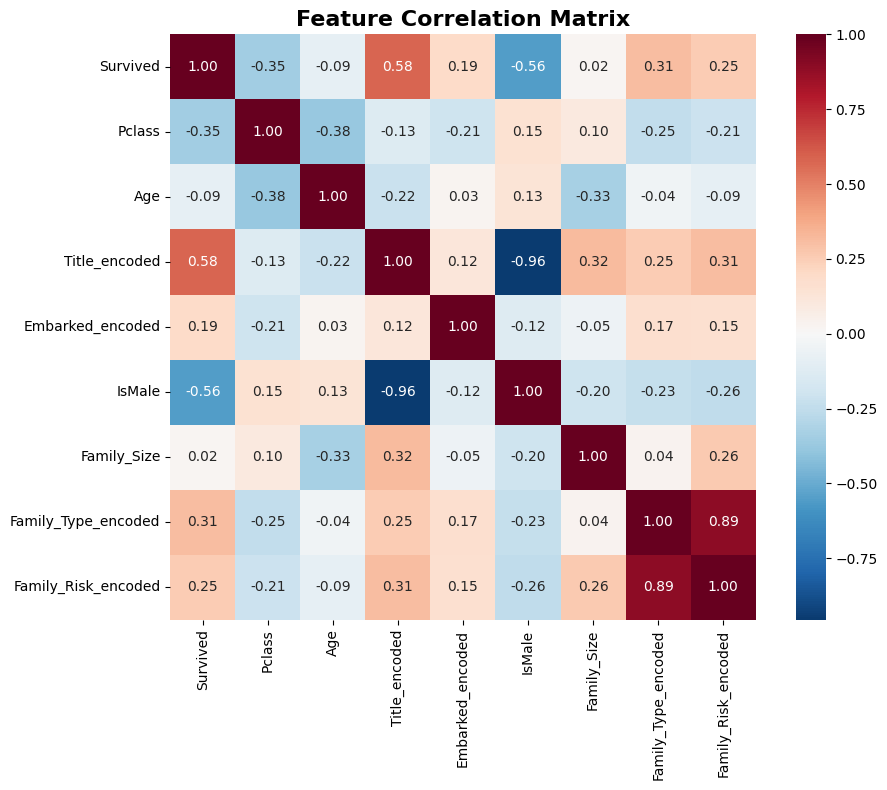

In [733]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_matrix(df, figsize=(10, 8), target_col='Survived'):
    """
    Plot correlation matrix heatmap.
    """
    # Calculate correlation matrix
    corr_matrix = df.corr()
    
    # Create plot
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, 
                annot=True,           # Show correlation values
                cmap='RdBu_r',        # Red-Blue colormap
                center=0,             # Center colormap at 0
                square=True,          # Square cells
                fmt='.2f')            # 2 decimal places
    
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def analyze_correlations(df, target_col='Survived', threshold=0.1):
    """
    Analyze correlations and show insights.
    """
    # Calculate correlations
    corr_matrix = df.corr()
    target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)
    
    print("📊 CORRELATION ANALYSIS:")
    print("=" * 40)
    
    # Show correlations with target
    print(f"\n🎯 Correlations with {target_col}:")
    print("-" * 30)
    for feature, corr in target_corr.items():
        if feature != target_col and abs(corr) >= threshold:
            direction = "📈 Positive" if corr > 0 else "📉 Negative"
            strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
            print(f"{feature:<20} {corr:>6.3f} ({direction}, {strength})")
    
    # Find highly correlated feature pairs
    print(f"\n🔗 Highly Correlated Features (>0.7):")
    print("-" * 35)
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                feature1 = corr_matrix.columns[i]
                feature2 = corr_matrix.columns[j]
                high_corr_pairs.append((feature1, feature2, corr_val))
                print(f"{feature1} ↔ {feature2}: {corr_val:.3f}")
    
    if not high_corr_pairs:
        print("No highly correlated features found.")
    
    # Feature selection suggestions
    print(f"\n💡 FEATURE SELECTION INSIGHTS:")
    print("-" * 32)
    
    # Most important features
    top_features = target_corr[target_corr.index != target_col].head(5)
    print("🏆 Top 5 features correlated with target:")
    for i, (feature, corr) in enumerate(top_features.items(), 1):
        print(f"   {i}. {feature} ({corr:.3f})")
    
    # Multicollinearity warning
    if high_corr_pairs:
        print("\n⚠️  MULTICOLLINEARITY WARNING:")
        print("   Consider removing one feature from highly correlated pairs")
        print("   to avoid redundancy and improve model performance.")

def correlation_summary(df, target_col='Survived'):
    """
    Quick correlation summary without plots.
    """
    corr_with_target = df.corr()[target_col].abs().sort_values(ascending=False)
    
    print(f"🎯 CORRELATION WITH {target_col.upper()}:")
    print("-" * 30)
    for feature, corr in corr_with_target.items():
        if feature != target_col:
            print(f"{feature:<20} {corr:6.3f}")

# Usage examples:

# 1. Full analysis with heatmap
analyze_correlations(df_train)
plot_correlation_matrix(df_train)

# 2. Quick summary only
# correlation_summary(df_train)

# 3. Custom target column
# analyze_correlations(df_train, target_col='Age', threshold=0.2)

In [734]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def train_xgb_model(df_train, df_test, df_submision):

    y_train = df_train['Survived'].copy()
    X_train = df_train.drop(columns=['Survived']).copy()
    
    param_grid = {
        'n_estimators': [25, 50],           # Much fewer trees
        'max_depth': [2, 3],                # Very shallow trees
        'learning_rate': [0.01, 0.03],     # Much slower learning
        'subsample': [0.5, 0.7],           # More row sampling
        'colsample_bytree': [0.5, 0.7],    # More column sampling
        'reg_alpha': [1.0, 2.0],           # Strong L1 regularization
        'reg_lambda': [1.0, 2.0],          # Strong L2 regularization
        'min_child_weight': [5, 10],       # Larger minimum leaf weight
        'gamma': [0.5, 1.0],               # Higher minimum split loss
    }
    
    xgb_model = xgb.XGBClassifier(random_state=42)
    
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
                                xgb_model, 
                                param_grid=param_grid, 
                                scoring='roc_auc', 
                                cv=cv_strategy, 
                                n_jobs=-1, 
                                verbose=1
                            )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")
    
    best_model = grid_search.best_estimator_
    
    predictions = best_model.predict(df_test)
    
    print(f"Predicted deaths: {(predictions == 0).sum()}")
    print(f"Predicted survivors: {(predictions == 1).sum()}")
    print(f"Survival rate: {predictions.mean():.1%}")

    df_submission_copy = df_submision.copy()
    df_submission_copy['Survived'] = predictions
    df_submission_copy.to_csv('data/XGB_predictions.csv', index=False)
    
    print("✅ Predictions saved to 'data/XGB_predictions.csv'")
    
    return best_model
# Best ROC-AUC: 0.8780


Best parameters: {'colsample_bytree': 0.7, 'gamma': 0.5, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 50, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7}

In [735]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

def train_svm_model(df_train, df_test, df_submision):

    y_train = df_train['Survived'].copy()
    X_train = df_train.drop(columns=['Survived']).copy()
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_score = model.score(X_train_scaled, y_train)
    
    print(f"Training accuracy: {train_score:.3f}")
    
    X_test_scaled = scaler.transform(df_test)
    
    predictions = model.predict(X_test_scaled)
    
    print(f"Predicted deaths: {(predictions == 0).sum()}")
    print(f"Predicted survivors: {(predictions == 1).sum()}")
    print(f"Survival rate: {predictions.mean():.1%}")

    df_submission_copy = df_submision.copy()
    df_submission_copy['Survived'] = predictions
    df_submission_copy.to_csv('data/SVM_predictions.csv', index=False)
    
    print("✅ Predictions saved to 'data/SVM_predictions.csv'")
    
    
    return model, scaler


In [736]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def train_logistic_regression(df_train, df_test, df_submision):
    """
    Simple logistic regression training function.
    """
    # Prepare data
    y_train = df_train['Survived'].copy()
    X_train = df_train.drop(columns=['Survived']).copy()
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Train logistic regression
    model = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    # Check performance
    train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_pred_proba)
    
    train_score = model.score(X_train_scaled, y_train)
    
    print("🎯 LOGISTIC REGRESSION RESULTS:")
    print("-" * 35)
    print(f"Training accuracy: {train_score:.3f}")
    print(f"Training AUC: {train_auc:.3f}")
    
    X_test_scaled = scaler.transform(df_test)
    
    predictions = model.predict(X_test_scaled)
    
    print(f"Predicted deaths: {(predictions == 0).sum()}")
    print(f"Predicted survivors: {(predictions == 1).sum()}")
    print(f"Survival rate: {predictions.mean():.1%}")

    df_submission_copy = df_submision.copy()
    df_submission_copy['Survived'] = predictions
    df_submission_copy.to_csv('data/LR_predictions.csv', index=False)
    
    print("✅ Predictions saved to 'data/LR_predictions.csv'")

    
    return model, scaler

In [737]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def evaluate_lr_model(model, scaler, df_validation):
    """
    Evaluate Logistic Regression model on validation data.
    """
    y_val = df_validation['Survived'].copy()
    X_val = df_validation.drop(columns=['Survived']).copy()
    
    # Scale validation data using training scaler
    X_val_scaled = scaler.transform(X_val)
    
    # Predictions
    y_pred = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probability of survival
    
    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    print("🎯 LOGISTIC REGRESSION EVALUATION:")
    print("-" * 35)
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"AUC-ROC: {auc:.4f}")
    
    # Detailed breakdown
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_val, y_pred, target_names=['Died', 'Survived']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"        Predicted")
    print(f"Actual  Died  Survived")
    print(f"Died    {cm[0,0]:4d}  {cm[0,1]:4d}")
    print(f"Survived {cm[1,0]:4d}  {cm[1,1]:4d}")
    
    return accuracy, auc

In [738]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def evaluate_svm_model(model, scaler, df_validation):

    y_val = df_validation['Survived'].copy()
    X_val = df_validation.drop(columns=['Survived']).copy()
    
    X_val_scaled = scaler.transform(X_val)

    y_pred = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probability of survival
    
    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    print("🎯 SVM MODEL EVALUATION:")
    print("-" * 30)
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"AUC-ROC: {auc:.4f}")
    
    # Detailed breakdown
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_val, y_pred, target_names=['Died', 'Survived']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"        Predicted")
    print(f"Actual  Died  Survived")
    print(f"Died    {cm[0,0]:4d}  {cm[0,1]:4d}")
    print(f"Survived {cm[1,0]:4d}  {cm[1,1]:4d}")
    
    return accuracy, auc


In [739]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def evaluate_xgb_model(model, df_validation):
    
    y_val = df_validation['Survived'].copy()
    X_val = df_validation.drop(columns=['Survived']).copy()
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]  # Probability of survival

    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    print("🎯 MODEL EVALUATION:")
    print("-" * 30)
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"AUC-ROC:  {auc:.4f}")
    
    # Detailed breakdown
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_val, y_pred, target_names=['Died', 'Survived']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"Actual    Died  Survived")
    print(f"Died      {cm[0,0]:4d}     {cm[0,1]:4d}")
    print(f"Survived  {cm[1,0]:4d}     {cm[1,1]:4d}")
    
    return accuracy, auc

In [740]:
from sklearn.metrics import roc_auc_score

def evaluate_lr_overfitting(model, scaler, df_train, df_validation):
    """
    Check for overfitting in Logistic Regression model.
    """
    # Training performance
    y_train = df_train['Survived']
    X_train = df_train.drop(columns=['Survived'])
    X_train_scaled = scaler.transform(X_train)  # Scale training data
    train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
    train_auc = roc_auc_score(y_train, train_pred_proba)
    
    # Validation performance
    y_val = df_validation['Survived']
    X_val = df_validation.drop(columns=['Survived'])
    X_val_scaled = scaler.transform(X_val)  # Scale validation data
    val_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred_proba)
    
    print("🔍 LOGISTIC REGRESSION OVERFITTING CHECK:")
    print("-" * 40)
    print(f"Training AUC:   {train_auc:.4f}")
    print(f"Validation AUC: {val_auc:.4f}")
    print(f"Gap:            {train_auc - val_auc:.4f}")
    
    if train_auc - val_auc > 0.05:
        print("🚨 OVERFITTING DETECTED!")
        print("   - Training performance much better than validation")
        print("   - Model memorized training data")
        print("   - Reduce model complexity or get more data")
    elif train_auc - val_auc < -0.02:
        print("🤔 UNDERFITTING DETECTED!")
        print("   - Validation better than training (unusual)")
        print("   - Increase model complexity")
    else:
        print("✅ GOOD FIT!")
        print("   - Training and validation performance similar")


In [741]:
from sklearn.metrics import roc_auc_score

def evaluate_svm_overfitting(model, scaler, df_train, df_validation):
    """
    Check for overfitting in SVM model.
    """
    # Training performance
    y_train = df_train['Survived']
    X_train = df_train.drop(columns=['Survived'])
    X_train_scaled = scaler.transform(X_train)  # Scale training data
    train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
    train_auc = roc_auc_score(y_train, train_pred_proba)
    
    # Validation performance
    y_val = df_validation['Survived']
    X_val = df_validation.drop(columns=['Survived'])
    X_val_scaled = scaler.transform(X_val)  # Scale validation data
    val_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred_proba)
    
    print("🔍 SVM OVERFITTING CHECK:")
    print("-" * 25)
    print(f"Training AUC:   {train_auc:.4f}")
    print(f"Validation AUC: {val_auc:.4f}")
    print(f"Gap:            {train_auc - val_auc:.4f}")
    
    if train_auc - val_auc > 0.05:
        print("🚨 OVERFITTING DETECTED!")
        print("   - Training performance much better than validation")
        print("   - Model memorized training data")
        print("   - Reduce model complexity or get more data")
    elif train_auc - val_auc < -0.02:
        print("🤔 UNDERFITTING DETECTED!")
        print("   - Validation better than training (unusual)")
        print("   - Increase model complexity")
    else:
        print("✅ GOOD FIT!")
        print("   - Training and validation performance similar")


In [ ]:
def evaluate_xgb_overfitting(model, df_train, df_validation):

    # Training performance
    y_train = df_train['Survived']
    X_train = df_train.drop(columns=['Survived'])
    train_pred_proba = model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, train_pred_proba)
    
    # Validation performance
    y_val = df_validation['Survived']
    X_val = df_validation.drop(columns=['Survived'])
    val_pred_proba = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred_proba)
    
    print("🔍 OVERFITTING CHECK:")
    print("-" * 25)
    print(f"Training AUC:   {train_auc:.4f}")
    print(f"Validation AUC: {val_auc:.4f}")
    print(f"Gap:            {train_auc - val_auc:.4f}")
    
    if train_auc - val_auc > 0.05:
        print("🚨 OVERFITTING DETECTED!")
        print("   - Training performance much better than validation")
        print("   - Model memorized training data")
        print("   - Reduce model complexity or get more data")
    elif train_auc - val_auc < -0.02:
        print("🤔 UNDERFITTING DETECTED!")
        print("   - Validation better than training (unusual)")
        print("   - Increase model complexity")
    else:
        print("✅ GOOD FIT!")
        print("   - Training and validation performance similar")
    
    print()
    y_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_pred)
    print(f"Validation accuracy: {val_accuracy:.3f}")

In [743]:
lr_model, lr_scaler = train_logistic_regression(df_train, df_test, df_submision)

🎯 LOGISTIC REGRESSION RESULTS:
-----------------------------------
Training accuracy: 0.838
Training AUC: 0.877
Predicted deaths: 248
Predicted survivors: 170
Survival rate: 40.7%
✅ Predictions saved to 'data/LR_predictions.csv'


In [744]:
evaluate_lr_model(lr_model, lr_scaler, df_validation)

🎯 LOGISTIC REGRESSION EVALUATION:
-----------------------------------
Accuracy: 0.8134 (81.3%)
AUC-ROC: 0.8659

Detailed Classification Report:
              precision    recall  f1-score   support

        Died       0.84      0.87      0.85        83
    Survived       0.77      0.73      0.75        51

    accuracy                           0.81       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.81      0.81      0.81       134


Confusion Matrix:
        Predicted
Actual  Died  Survived
Died      72    11
Survived   14    37


(0.8134328358208955, 0.8659343255374439)

In [745]:
evaluate_lr_overfitting(lr_model, lr_scaler, df_train, df_validation)

🔍 LOGISTIC REGRESSION OVERFITTING CHECK:
----------------------------------------
Training AUC:   0.8766
Validation AUC: 0.8659
Gap:            0.0107
✅ GOOD FIT!
   - Training and validation performance similar


In [746]:
model, scaler = train_svm_model(df_train, df_test, df_submision)


Training accuracy: 0.838
Predicted deaths: 256
Predicted survivors: 162
Survival rate: 38.8%
✅ Predictions saved to 'data/SVM_predictions.csv'


In [747]:
evaluate_svm_model(model, scaler, df_validation)


🎯 SVM MODEL EVALUATION:
------------------------------
Accuracy: 0.8134 (81.3%)
AUC-ROC: 0.8262

Detailed Classification Report:
              precision    recall  f1-score   support

        Died       0.83      0.88      0.85        83
    Survived       0.78      0.71      0.74        51

    accuracy                           0.81       134
   macro avg       0.81      0.79      0.80       134
weighted avg       0.81      0.81      0.81       134


Confusion Matrix:
        Predicted
Actual  Died  Survived
Died      73    10
Survived   15    36


(0.8134328358208955, 0.8262461611150484)

In [748]:
evaluate_svm_overfitting(model, scaler, df_train, df_validation)

🔍 SVM OVERFITTING CHECK:
-------------------------
Training AUC:   0.8836
Validation AUC: 0.8262
Gap:            0.0574
🚨 OVERFITTING DETECTED!
   - Training performance much better than validation
   - Model memorized training data
   - Reduce model complexity or get more data


In [749]:
xgb_model = train_xgb_model(df_train, df_test, df_submision)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best parameters: {'colsample_bytree': 0.7, 'gamma': 0.5, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 50, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.7}
Best ROC-AUC: 0.8740
Predicted deaths: 266
Predicted survivors: 152
Survival rate: 36.4%
✅ Predictions saved to 'data/XGB_predictions.csv'


In [750]:
evaluate_xgb_model(xgb_model, df_validation)

🎯 MODEL EVALUATION:
------------------------------
Accuracy: 0.7985 (79.9%)
AUC-ROC:  0.8600

Detailed Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.88      0.84        83
    Survived       0.77      0.67      0.72        51

    accuracy                           0.80       134
   macro avg       0.79      0.77      0.78       134
weighted avg       0.80      0.80      0.80       134


Confusion Matrix:
              Predicted
Actual    Died  Survived
Died        73       10
Survived    17       34


(0.7985074626865671, 0.8600283486888731)

In [751]:
evaluate_xgb_overfitting(xgb_model, df_train, df_validation)

🔍 OVERFITTING CHECK:
-------------------------
Training AUC:   0.8849
Validation AUC: 0.8600
Gap:            0.0249
✅ GOOD FIT!
   - Training and validation performance similar
Nuo cia
Validation accuracy: 0.799
